In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install "zarr>=2.16.0,<3.0.0" numcodecs umap-learn

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.3/211.3 kB 18.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 153.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 44.2 MB/s eta 0:00:00
  Created wheel for asciitree: filename=asciitree-0.3.3-py3-none-any.whl size=5031 sha256=aeb84b1c659fdc37401268d1af9702a8bd1a7873eff7146d8dc5f24a762ce6cc
  Stored in directory: /root/.cache/pip/wheels/a5/d7/98/f56ae733748cd0fa577172bda0e73e0b1f1793c98e09b9e458
Successfully built asciitree


In [3]:
import os
import shutil
import datetime
import gc
import numpy as np
import tensorflow as tf
import random
from typing import Literal
import matplotlib.pyplot as plt
import pandas as pd
import math
from dataclasses import dataclass
from sklearn.metrics import confusion_matrix
import seaborn as sns

In [4]:
ModelType = Literal["pair", "triplet"]

@dataclass
class ModelConfig:
    type: ModelType

@dataclass
class DataConfig:
    authors: int
    authors_range: range
    original_shape: tuple[int, int, int]
    model_input_shape: tuple[int, int, int]

    def __post_init__(self):
        # Validate authors
        assert self.authors > 0, "authors must be positive"

        # Validate range consistency
        assert isinstance(self.authors_range, range), "authors_range must be a range"

        expected_len = self.authors_range.stop - self.authors_range.start
        assert expected_len == self.authors, (
            f"authors ({self.authors}) != range size ({expected_len})"
        )

        # Validate shapes
        assert self.original_shape[-1] in (1, 3), "invalid original channels"
        assert self.model_input_shape[-1] in (1, 3), "invalid input channels"


@dataclass
class TrainingConfig:
    epochs: int
    seed: int
    val_ratio: float

    def __post_init__(self):
        assert 0 < self.val_ratio < 1, "val_ratio must be between 0 and 1"


@dataclass
class BatchConfig:
    train: int
    validation: int
    test: int

    def __post_init__(self):
        assert self.train > 0
        assert self.validation > 0
        assert self.test > 0


@dataclass
class Config:
    project_path: str
    dataset: str
    model: ModelConfig
    data: DataConfig
    training: TrainingConfig
    batch: BatchConfig
    current_time: str

In [5]:
config = Config(
    project_path='drive/MyDrive/author-handwriting-recog',
    dataset='dataset_4_ImagesLinesRemoved_20260310-153450',
    model=ModelConfig(type="triplet"),
    data=DataConfig(
        authors=100,
        authors_range=range(0, 100),
        original_shape=(180, 360, 1),
        model_input_shape=(120, 240, 3),
    ),
    training=TrainingConfig(
        epochs=30,
        seed=42,
        val_ratio=0.25
    ),
    batch=BatchConfig(
        train=32,
        validation=16,
        test=8,
    ),
    current_time=datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
)

In [6]:
def upload_source(source: str, source_dest: str):
    if os.path.exists(source_dest):
        shutil.rmtree(source_dest)

    shutil.copytree(source, source_dest)

In [7]:
src_drive = f"{config.project_path}/src"
src_local = "./src"

In [8]:
src_data_drive = f"{config.project_path}/data/datasets/180_360_90"
src_data_local = f"./dataset"

In [9]:
upload_source(source=src_drive, source_dest=src_local)

In [10]:
upload_source(source=src_data_drive, source_dest=src_data_local)

In [11]:
random.seed(config.training.seed)
np.random.seed(config.training.seed)
tf.random.set_seed(config.training.seed)

In [12]:
from src.io import LoggerFactory
from src.datasets.loaders import SelectiveDataLoader
from src.generators import (
    AugmentationPipeline,
    AugmentationOps,
    AugmentImage,
    BaseGenerator,
    DataGenerator,
    TripletGenerator,
)

In [ ]:
from src.models import MobileNetV2Backbone, TripletLoss
from src.training import (
    get_default_callbacks,
    ModelTrainerFactory,
)
from src.evaluator import (
    TripletEvaluator,
)

In [ ]:
from src.evaluator.embedding_utils import EmbeddingExtractor
from src.evaluator.embedding_strategy import (
    StrategyPipeline,
    OneNNStrategy,
    MeanStrategy,
    CentroidStrategy,
    TopKStrategy,
    PatchAggregator,
    VoteAggregator,
    ScoreAggregator,
)
from src.evaluator import EmbeddingEvaluator, EmbeddingVisualizer

In [14]:
logger = LoggerFactory.get_logger(
    "mobile_test_100_4",
    log_dir=f"./logs_{config.current_time}",
    file_prefix=f"mobile_triplet_{config.current_time}"
)

In [15]:
dataset_path = f"dataset/{config.dataset}.tar.gz"

In [16]:
!tar -xzf {dataset_path} -C ./

In [17]:
loader = SelectiveDataLoader(
    dataset_path=f"./{config.dataset}.zarr",
    seed=config.training.seed
)

In [18]:
train, val, test = loader.build(
      author_range=config.data.authors_range,
      validation_fraction=config.training.val_ratio,
  )

13:32:26 - src.datasets.loaders.selective_data_loader - INFO - Total patches selected: 63969
13:32:26 - src.datasets.loaders.selective_data_loader - INFO - Train: 47976 | Val: 15993 | Test: 4372
13:32:26 - src.datasets.loaders.selective_data_loader - INFO - Avg non_test patches per author: 639.69 | Min: 399 | Max: 883
13:32:26 - src.datasets.loaders.selective_data_loader - INFO - Avg test patches per author: 43.72 | Min: 34 | Max: 49
13:32:26 - src.datasets.loaders.selective_data_loader - INFO - Image shape: (180, 360)
13:32:26 - src.datasets.loaders.selective_data_loader - INFO - Zarr chunk shape: (64, 180, 360)


In [19]:
ops = AugmentationOps(
    rotation_range=6,
    width_shift_range=0.04,
    height_shift_range=0.05,
    horizontal_flip=False,
    resize_dim=config.data.model_input_shape[:2],
    brightness_delta=0.04,
    contrast_range=(0.95, 1.05),
    noise_stddev=0.01,
    zoom_range=(0.95, 1.05),
)
pipeline_train = AugmentationPipeline([
    ops.rotate,
    ops.zoom,
    ops.shift,
    ops.resize,
    ops.to_rgb,
    ops.clip_255,
    ops.mobilenet_preprocess,
])
pipeline = AugmentationPipeline([
    ops.resize,
    ops.to_rgb,
    ops.clip_255,
    ops.mobilenet_preprocess,
])
augment_train = AugmentImage(pipeline_train)
augment = AugmentImage(pipeline)

In [20]:
train_triplet = TripletGenerator(
    cache=train.cache,
    labels=train.labels,
    indices=train.indices,
    batch_size=config.batch.train,
    seed=config.training.seed,
    augment=augment_train
)
val_triplet = TripletGenerator(
    cache=val.cache,
    labels=val.labels,
    indices=val.indices,
    batch_size=config.batch.validation,
    seed=config.training.seed,
    augment=augment
)
test_triplet = TripletGenerator(
    cache=test.cache,
    labels=test.labels,
    indices=test.indices,
    batch_size=config.batch.test,
    seed=config.training.seed,
    augment=augment
)

In [21]:
def display_generator_info(generator: BaseGenerator):
    config = generator.get_config()
    logger.info(f"Generator: {generator.__class__.__name__}")
    logger.info(f"Number of samples: {config['num_samples']}")
    logger.info(f"Batch size: {config['batch_size']}")
    logger.info(f"Steps per epoch: {config['steps_per_epoch']}")
    logger.info(f"Shape: {config['patch_shape']}")
    logger.info(f"Number of authors: {config['num_authors']}")

In [22]:
display_generator_info(train_triplet)

13:32:26 - mobile_test_100_4 - INFO - Generator: TripletGenerator
13:32:26 - mobile_test_100_4 - INFO - Number of samples: 47976
13:32:26 - mobile_test_100_4 - INFO - Batch size: 32
13:32:26 - mobile_test_100_4 - INFO - Steps per epoch: 1500
13:32:26 - mobile_test_100_4 - INFO - Shape: (180, 360)
13:32:26 - mobile_test_100_4 - INFO - Number of authors: 100


In [23]:
display_generator_info(val_triplet)

13:32:26 - mobile_test_100_4 - INFO - Generator: TripletGenerator
13:32:26 - mobile_test_100_4 - INFO - Number of samples: 15993
13:32:26 - mobile_test_100_4 - INFO - Batch size: 16
13:32:26 - mobile_test_100_4 - INFO - Steps per epoch: 1000
13:32:26 - mobile_test_100_4 - INFO - Shape: (180, 360)
13:32:26 - mobile_test_100_4 - INFO - Number of authors: 100


In [24]:
display_generator_info(test_triplet)

13:32:26 - mobile_test_100_4 - INFO - Generator: TripletGenerator
13:32:26 - mobile_test_100_4 - INFO - Number of samples: 4372
13:32:26 - mobile_test_100_4 - INFO - Batch size: 8
13:32:26 - mobile_test_100_4 - INFO - Steps per epoch: 547
13:32:26 - mobile_test_100_4 - INFO - Shape: (180, 360)
13:32:26 - mobile_test_100_4 - INFO - Number of authors: 100


In [32]:
trainer = ModelTrainerFactory.create(
    backbone=MobileNetV2Backbone(freeze_base=False, fine_tune_at=100),
    input_shape=config.data.model_input_shape,
    num_authors=config.data.authors,
    train_generator=train_triplet,
    val_generator=val_triplet,
    model_name="mobilenet_triplet",
    model_type=config.model.type,
)

13:33:56 - src.training.base_metric_trainer - INFO - [EmbeddingConfig] author=100 | embedding_dim=224 | projection_dim=448


In [33]:
trainer.initialize_model()

/content/src/models/backbones/mobile_net.py:13: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = tf.keras.applications.MobileNetV2(


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:424: UserWarning: `build()` was called on layer 'mobile_triplet', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


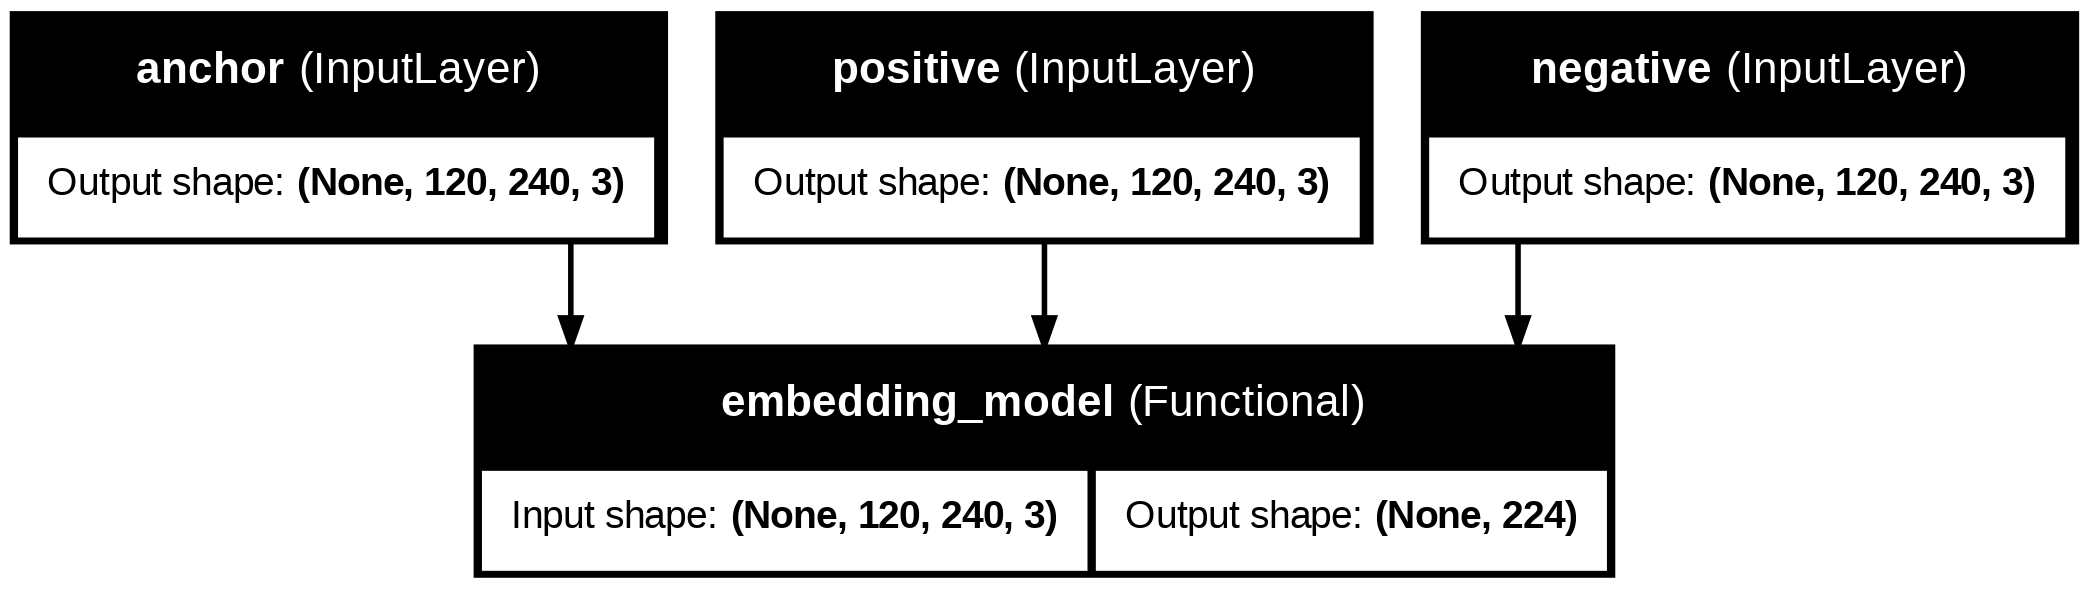

In [34]:
tf.keras.utils.plot_model(
    trainer.siamese_network,
    show_shapes=True,
    show_layer_names=True,
)

In [35]:
trainer.siamese_network.summary()

Model: "siamese_triplet_model"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ anchor (InputLayer) │ (None, 120, 240,  │          0 │ -                 │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ positive            │ (None, 120, 240,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ negative            │ (None, 120, 240,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_model     │ (None, 224)       │  2,935,136 │ anchor[0][0],     │
│ (Functional)        │                   │            │ positive[0][0],   │
│                     │                   │            │ negative[0][0]    │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,935,136 (11.20 MB)

 Trainable params: 2,537,248 (9.68 MB)

 Non-trainable params: 397,888 (1.52 MB)

In [36]:
trainer.embedding_model.summary()

Model: "embedding_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 120, 240, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 4, 8, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ projection_dense_1 (Dense)      │ (None, 448)            │       573,888 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 448)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 448)            │         1,792 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_projection (Dense)    │ (None, 224)            │       100,576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 224)            │           896 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ l2_normalization                │ (None, 224)            │             0 │
│ (L2Normalization)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,935,136 (11.20 MB)

 Trainable params: 2,537,248 (9.68 MB)

 Non-trainable params: 397,888 (1.52 MB)

In [37]:
trainer.compile(
    loss=TripletLoss(margin=0.4),
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    metrics=[
        tf.keras.metrics.Mean(name="ap_sim"),
        tf.keras.metrics.Mean(name="an_sim"),
        tf.keras.metrics.Mean(name="margin"),
        tf.keras.metrics.Mean(name="triplet_acc"),
    ],
)

In [39]:
callbacks = get_default_callbacks(
    model_name="mobile_siamese_triplet",
    monitor="val_loss",
    mode="min",
    patience=4,
    start_from_epoch=5,
    reduce_lr_patience=2,
)

In [40]:
history = trainer.train_model(
    epochs=config.training.epochs,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step - an_sim: -2.6738e-04 - ap_sim: 0.0584 - loss: 0.3469 - margin: 0.0586 - triplet_acc: 0.6200
Epoch 1: val_loss improved from None to 0.26562, saving model to checkpoints/mobile_siamese_triplet/best.keras

Epoch 1: finished saving model to checkpoints/mobile_siamese_triplet/best.keras
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 348s 194ms/step - an_sim: -4.7783e-04 - ap_sim: 0.1091 - loss: 0.3115 - margin: 0.1096 - triplet_acc: 0.6651 - val_an_sim: 0.0852 - val_ap_sim: 0.2601 - val_loss: 0.2656 - val_margin: 0.1749 - val_triplet_acc: 0.7232 - learning_rate: 1.0000e-05
Epoch 2/30
1499/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step - an_sim: 0.0022 - ap_sim: 0.2563 - loss: 0.2382 - margin: 0.2542 - triplet_acc: 0.7458
Epoch 2: val_loss improved from 0.26562 to 0.22313, saving model to checkpoints/mobile_siamese_triplet/best.keras

Epoch 2: finished saving model to checkpoints/mobile_siamese_triplet/best.keras
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 225s 150ms/st

In [41]:
def plot_keras_history(history: tf.keras.callbacks.History):

    df = pd.DataFrame(history.history)

    metrics = [col for col in df.columns if not col.startswith("val_")]

    n_metrics = len(metrics)
    n_cols = 2
    n_rows = math.ceil(n_metrics / n_cols)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 5 * n_rows))
    axes = axes.flatten()

    for i, metric in enumerate(metrics):
        ax = axes[i]

        ax.plot(df[metric], label=f"train_{metric}")

        val_metric = f"val_{metric}"
        if val_metric in df.columns:
            ax.plot(df[val_metric], label=f"val_{metric}")

        ax.set_title(metric)
        ax.set_xlabel("Epoch")
        ax.legend()

    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

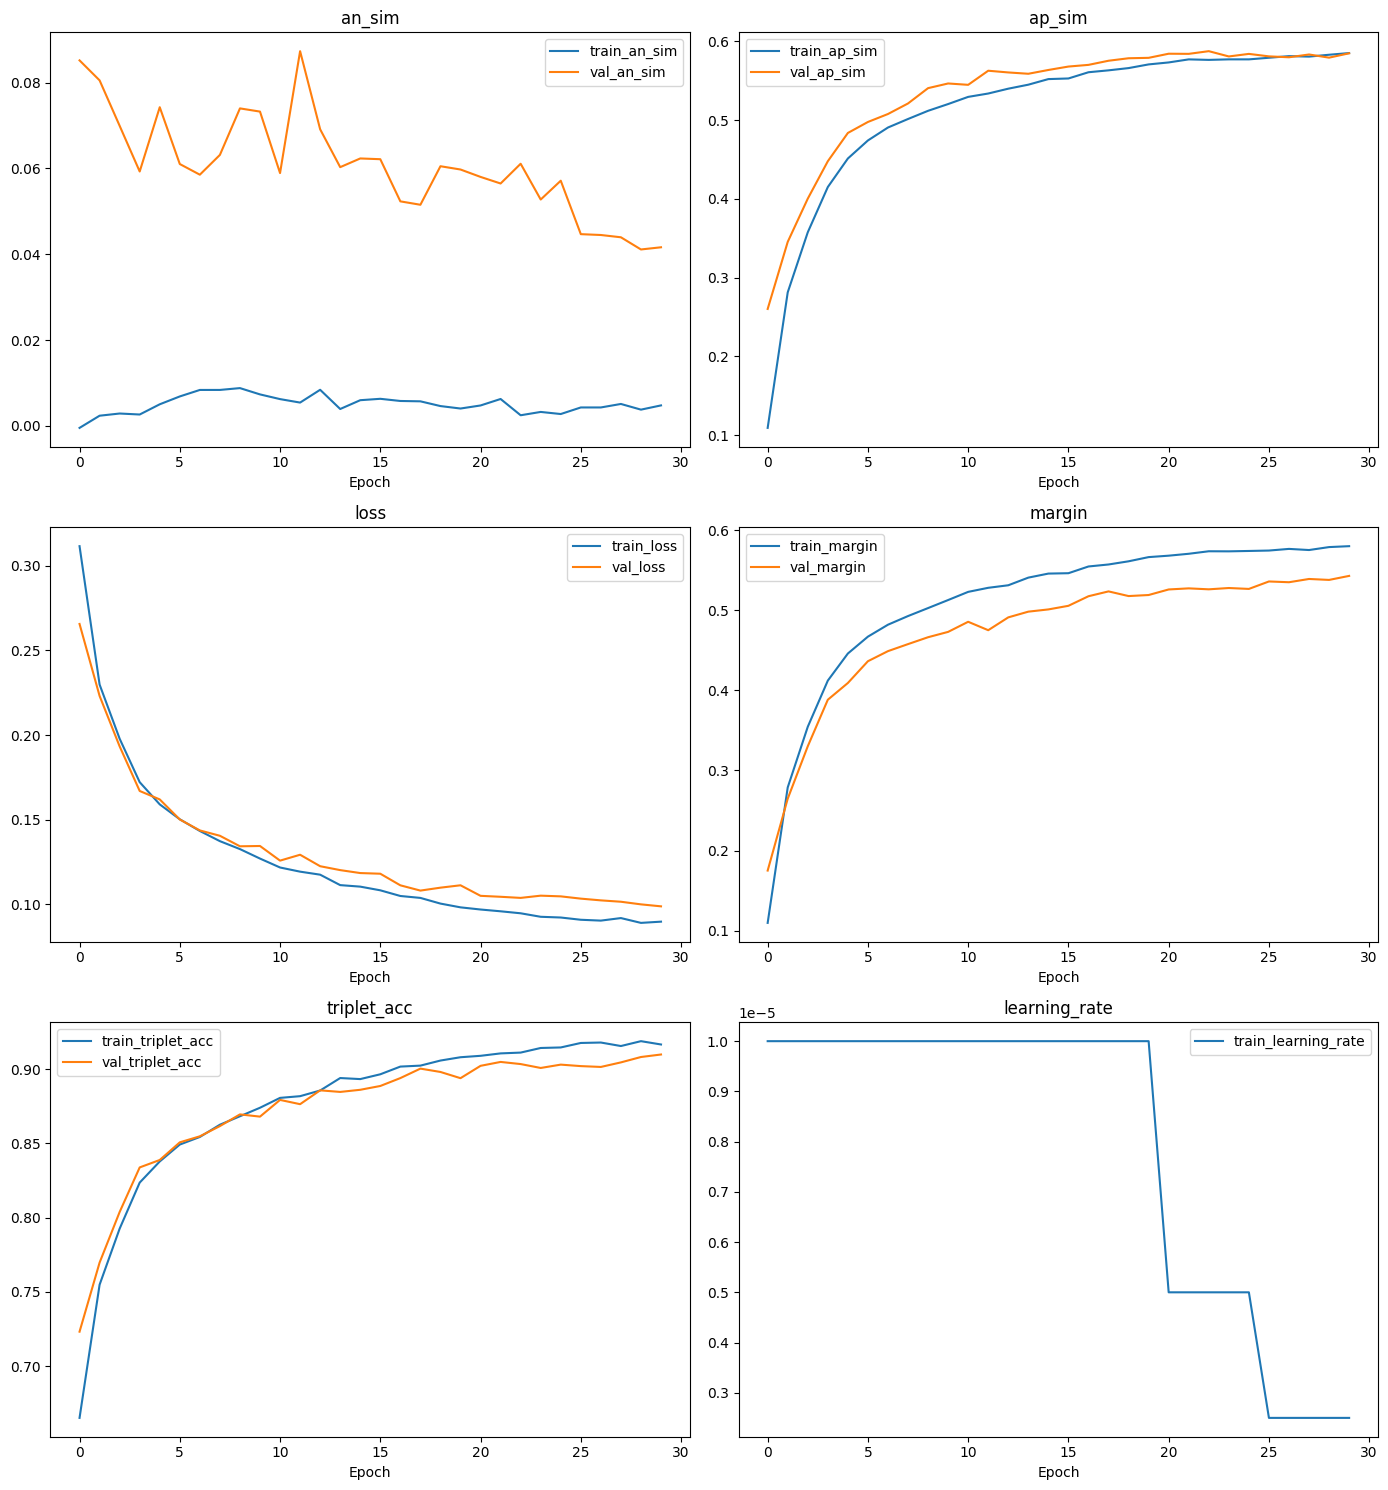

In [42]:
plot_keras_history(history)

In [43]:
os.makedirs("./models", exist_ok=True)
trainer.siamese_network.save(f"./models/mobilenet_siamese_model_100_{config.current_time}.keras")
trainer.embedding_model.save(f"./models/mobilenet_embedding_model_100_{config.current_time}.keras")

In [35]:
trainer.siamese_network.load_weights("./models/mobilenet_siamese_model_100_20260323-191301.keras")

In [44]:
metrics_val = trainer.evaluate_dict(val_triplet)
metrics_val

1000/1000 ━━━━━━━━━━━━━━━━━━━━ 44s 44ms/step - an_sim: 0.0451 - ap_sim: 0.5861 - loss: 0.0984 - margin: 0.5409 - triplet_acc: 0.9111


{'an_sim': 0.04513327777385712,
 'ap_sim': 0.5860774517059326,
 'loss': 0.09843281656503677,
 'margin': 0.5409443378448486,
 'triplet_acc': 0.9111486077308655}

In [45]:
metrics_test = trainer.evaluate_dict(test_triplet)
metrics_test

547/547 ━━━━━━━━━━━━━━━━━━━━ 37s 59ms/step - an_sim: 0.0094 - ap_sim: 0.6307 - loss: 0.0768 - margin: 0.6213 - triplet_acc: 0.9305


{'an_sim': 0.009384171105921268,
 'ap_sim': 0.6306912899017334,
 'loss': 0.07681503146886826,
 'margin': 0.621307373046875,
 'triplet_acc': 0.9304665923118591}

In [47]:
def build_author_confusion_matrix(
    df: pd.DataFrame,
    true_col: str = "author_i",
    pred_col: str = "author_j"
) -> pd.DataFrame:
    authors = sorted(df[true_col].unique())

    cm = confusion_matrix(
        df[true_col],
        df[pred_col],
        labels=authors
    )

    cm_df = pd.DataFrame(
        cm,
        index=authors,
        columns=authors
    )

    return cm_df

In [48]:
def display_heatmap(df: pd.DataFrame) -> None:
    plt.figure(figsize=(10, 8))
    sns.heatmap(df, cmap="Blues", linewidths=0.5)

    plt.xlabel("Predicted Author")
    plt.ylabel("True Author")
    plt.title("Confusion Matrix")
    plt.show()

In [50]:
triplet_evaluator = TripletEvaluator(
    model=trainer,
    logger=logger,
)

In [51]:
triplet_evaluator.data_generator = test_triplet
triplet_report = triplet_evaluator.evaluate()

15:32:37 - mobile_test_100_4 - INFO - === Triplet Evaluation Started ===
15:32:37 - mobile_test_100_4 - INFO - === Collecting triplet results ===
15:33:09 - mobile_test_100_4 - INFO - Total triplets collected: 4372
15:33:09 - mobile_test_100_4 - INFO - [LOCAL] acc=0.9398 gap=0.6193 error=0.0602 auc=0.9386
15:33:09 - mobile_test_100_4 - INFO - === Computing global metrics ===
15:33:09 - mobile_test_100_4 - INFO - === Global metrics computed ===
15:33:09 - mobile_test_100_4 - INFO - === Triplet Evaluation Finished ===


In [52]:
triplet_report.local_metrics.auc, triplet_report.local_metrics.triplet_accuracy

(0.9386046131541564, 0.9398444647758463)

In [ ]:
cm_df = build_author_confusion_matrix(
    triplet_report.df_triplets,
    true_col="anchor_label",
    pred_col="pred_label"
)
display_heatmap(cm_df)

In [53]:
triplet_report.global_metrics.df_by_score

,anchor_label,pred_label,accuracy,mean_gap,count,gap_norm,score
0,0,0,1.0,0.836213,36,0.933080,0.933080
1,1,1,1.0,0.610026,36,0.802224,0.802224
2,2,2,1.0,0.826431,46,0.927421,0.927421
3,3,3,1.0,0.655867,41,0.828744,0.828744
4,4,4,1.0,0.679547,41,0.842444,0.842444
...,...,...,...,...,...,...,...
95,95,95,1.0,0.598979,40,0.795833,0.795833
96,96,96,1.0,0.525648,38,0.753409,0.753409
97,97,97,1.0,0.899675,45,0.969795,0.969795
98,98,98,1.0,0.768922,43,0.894151,0.894151


In [ ]:
cm_df = build_author_confusion_matrix(
    triplet_report.global_metrics.df_by_score,
    true_col="anchor_label",
    pred_col="pred_label"
)
display_heatmap(cm_df)

In [54]:
train_gen = DataGenerator(
    split=train,
    batch_size=config.batch.train,
    seed=config.training.seed,
    augment=augment_train
)
val_gen = DataGenerator(
    split=val,
    batch_size=config.batch.validation,
    seed=config.training.seed,
    augment=augment
)
test_gen = DataGenerator(
    split=test,
    batch_size=config.batch.test,
    seed=config.training.seed,
    augment=augment
)

In [55]:
display_generator_info(train_gen)

15:34:11 - mobile_test_100_4 - INFO - Generator: DataGenerator
15:34:11 - mobile_test_100_4 - INFO - Number of samples: 47976
15:34:11 - mobile_test_100_4 - INFO - Batch size: 32
15:34:11 - mobile_test_100_4 - INFO - Steps per epoch: 1500
15:34:11 - mobile_test_100_4 - INFO - Shape: (180, 360)
15:34:11 - mobile_test_100_4 - INFO - Number of authors: 100


In [56]:
display_generator_info(val_gen)

15:34:12 - mobile_test_100_4 - INFO - Generator: DataGenerator
15:34:12 - mobile_test_100_4 - INFO - Number of samples: 15993
15:34:12 - mobile_test_100_4 - INFO - Batch size: 16
15:34:12 - mobile_test_100_4 - INFO - Steps per epoch: 1000
15:34:12 - mobile_test_100_4 - INFO - Shape: (180, 360)
15:34:12 - mobile_test_100_4 - INFO - Number of authors: 100


In [57]:
display_generator_info(test_gen)

15:34:13 - mobile_test_100_4 - INFO - Generator: DataGenerator
15:34:13 - mobile_test_100_4 - INFO - Number of samples: 4372
15:34:13 - mobile_test_100_4 - INFO - Batch size: 8
15:34:13 - mobile_test_100_4 - INFO - Steps per epoch: 547
15:34:13 - mobile_test_100_4 - INFO - Shape: (180, 360)
15:34:13 - mobile_test_100_4 - INFO - Number of authors: 100


In [60]:
extractor = EmbeddingExtractor(
    model=trainer.embedding_model,
    logger=logger,
)

In [ ]:
strategy_pipeline = StrategyPipeline(
    strategies=[
        OneNNStrategy(), MeanStrategy(), CentroidStrategy(), TopKStrategy(k=5),
    ],
    aggregators=[PatchAggregator(), VoteAggregator(), ScoreAggregator()],
    logger=logger,
)

In [61]:
emb_evaluator = EmbeddingEvaluator(
    extractor=extractor,
    pipeline=strategy_pipeline,
    logger=logger,
    seed=config.training.seed
)

In [ ]:
val_gen_results = emb_evaluator.evaluate(val_gen)

In [84]:
logger.info(f"Intra distance: {val_gen_results.intra_distance}")
logger.info(f"Inter distance: {val_gen_results.inter_distance}")

for strategy_name, agg_results in val_gen_results.strategy_results.items():

    logger.info(f"Strategy: {strategy_name}")

    for agg_name, result in agg_results.items():
        acc = result.metrics.get("accuracy", np.nan)
        logger.info(f"{agg_name.capitalize()} accuracy: {acc:.4f}")

    logger.info(f"{'-'*40}")

15:45:49 - mobile_test_100_4 - INFO - Intra distance: 0.43823262383088923
15:45:49 - mobile_test_100_4 - INFO - Inter distance: 0.9543170010247084
15:45:49 - mobile_test_100_4 - INFO - Strategy: 1nn
15:45:49 - mobile_test_100_4 - INFO - Patch accuracy: 0.4413
15:45:49 - mobile_test_100_4 - INFO - Vote accuracy:  1.0000
15:45:49 - mobile_test_100_4 - INFO - Score accuracy: 0.1000
15:45:49 - mobile_test_100_4 - INFO - ----------------------------------------
15:45:49 - mobile_test_100_4 - INFO - Strategy: mean
15:45:49 - mobile_test_100_4 - INFO - Patch accuracy: 0.3822
15:45:49 - mobile_test_100_4 - INFO - Vote accuracy:  0.7400
15:45:49 - mobile_test_100_4 - INFO - Score accuracy: 0.1500
15:45:49 - mobile_test_100_4 - INFO - ----------------------------------------
15:45:49 - mobile_test_100_4 - INFO - Strategy: centroid
15:45:49 - mobile_test_100_4 - INFO - Patch accuracy: 0.4364
15:45:49 - mobile_test_100_4 - INFO - Vote accuracy:  1.0000
15:45:49 - mobile_test_100_4 - INFO - Score a

In [63]:
test_gen_results = emb_evaluator.evaluate(test_gen)

15:34:46 - src.evaluator.embedding_evaluator - INFO - [EmbeddingEvaluator] Starting evaluation
15:34:46 - src.evaluator.embedding_analysis - INFO - [Analysis] Building author pair similarities
15:34:46 - src.evaluator.embedding_analysis - INFO - [Analysis] Building author embeddings
15:34:46 - src.evaluator.embedding_analysis - INFO - [Analysis] Built embeddings for 100 authors
15:34:47 - src.evaluator.embedding_analysis - INFO - [Analysis] Built 10000 author pairs
15:34:47 - src.evaluator.embedding_evaluator - INFO - [Pairs] Built in 0.84s
15:34:47 - src.evaluator.embedding_analysis - INFO - [Analysis] Running UMAP (this may take time...)


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


15:35:13 - src.evaluator.embedding_analysis - INFO - [Analysis] UMAP completed in 26.30s
15:35:13 - src.evaluator.embedding_evaluator - INFO - [UMAP] Completed in 26.30s
15:35:13 - src.evaluator.embedding_analysis - INFO - [Analysis] Starting intra/inter distance computation
15:35:13 - src.evaluator.embedding_analysis - INFO - [Analysis] Sampling 10000 pairs
15:35:13 - src.evaluator.embedding_analysis - INFO - [Analysis] Valid pairs after filtering: 9997
15:35:13 - src.evaluator.embedding_analysis - INFO - [Analysis] intra=0.3691 | inter=0.9918 | ratio=0.3721
15:35:13 - src.evaluator.embedding_analysis - INFO - [Analysis] Distance computation completed in 0.04s
15:35:13 - src.evaluator.embedding_evaluator - INFO - [EmbeddingEvaluator] Evaluating strategies: ['1nn', 'mean', 'centroid', 'topk']
15:35:13 - src.evaluator.embedding_analysis - INFO - [Pipeline] Applying strategy: 1nn
15:35:13 - src.evaluator.embedding_analysis - INFO - [Strategy:1NN] Computing similarity matrix
15:35:13 - sr

In [64]:
logger.info(f"Intra distance: {test_gen_results.intra_distance}")
logger.info(f"Inter distance: {test_gen_results.inter_distance}")

for strategy_name, agg_results in test_gen_results.strategy_results.items():

    logger.info(f"Strategy: {strategy_name}")

    for agg_name, result in agg_results.items():
        acc = result.metrics.get("accuracy", np.nan)
        logger.info(f"{agg_name.capitalize()} accuracy: {acc:.4f}")

    logger.info(f"{'-'*40}")

15:35:39 - mobile_test_100_4 - INFO - Intra distance: 0.36907190389253874
15:35:39 - mobile_test_100_4 - INFO - Inter distance: 0.9918258444949152
15:35:39 - mobile_test_100_4 - INFO - Strategy: 1nn
15:35:39 - mobile_test_100_4 - INFO - Patch accuracy: 0.7219
15:35:39 - mobile_test_100_4 - INFO - Vote accuracy:  1.0000
15:35:39 - mobile_test_100_4 - INFO - Score accuracy: 0.3500
15:35:39 - mobile_test_100_4 - INFO - ----------------------------------------
15:35:39 - mobile_test_100_4 - INFO - Strategy: mean
15:35:39 - mobile_test_100_4 - INFO - Patch accuracy: 0.4712
15:35:39 - mobile_test_100_4 - INFO - Vote accuracy:  0.7100
15:35:39 - mobile_test_100_4 - INFO - Score accuracy: 0.2100
15:35:39 - mobile_test_100_4 - INFO - ----------------------------------------
15:35:39 - mobile_test_100_4 - INFO - Strategy: centroid
15:35:39 - mobile_test_100_4 - INFO - Patch accuracy: 0.5359
15:35:39 - mobile_test_100_4 - INFO - Vote accuracy:  0.9600
15:35:39 - mobile_test_100_4 - INFO - Score a

In [65]:
viz = EmbeddingVisualizer(
    report=test_gen_results,
    logger=logger,
    loader=test.loader,
)

In [ ]:
viz.set_strategy("1nn")

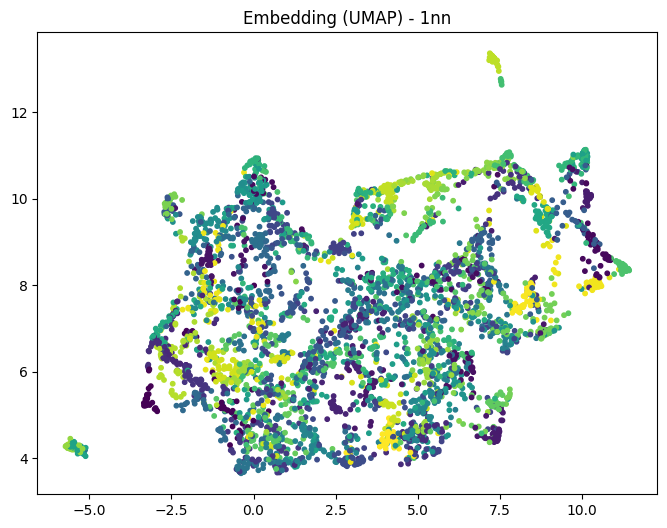

In [66]:
viz.plot_embeddings_2d()

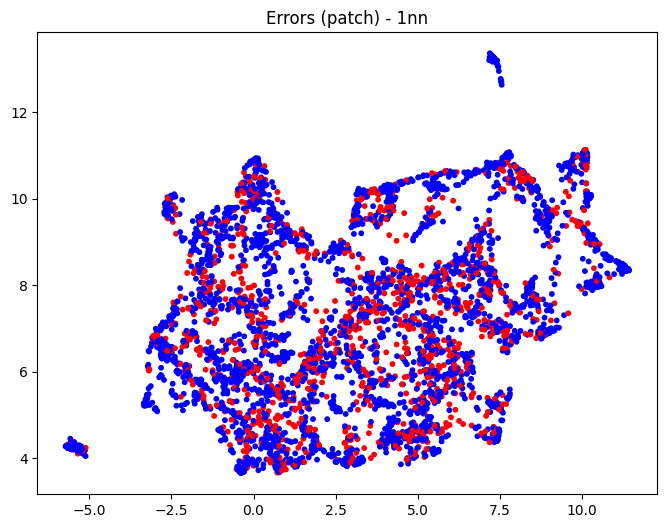

In [67]:
viz.plot_errors_2d(level="patch")

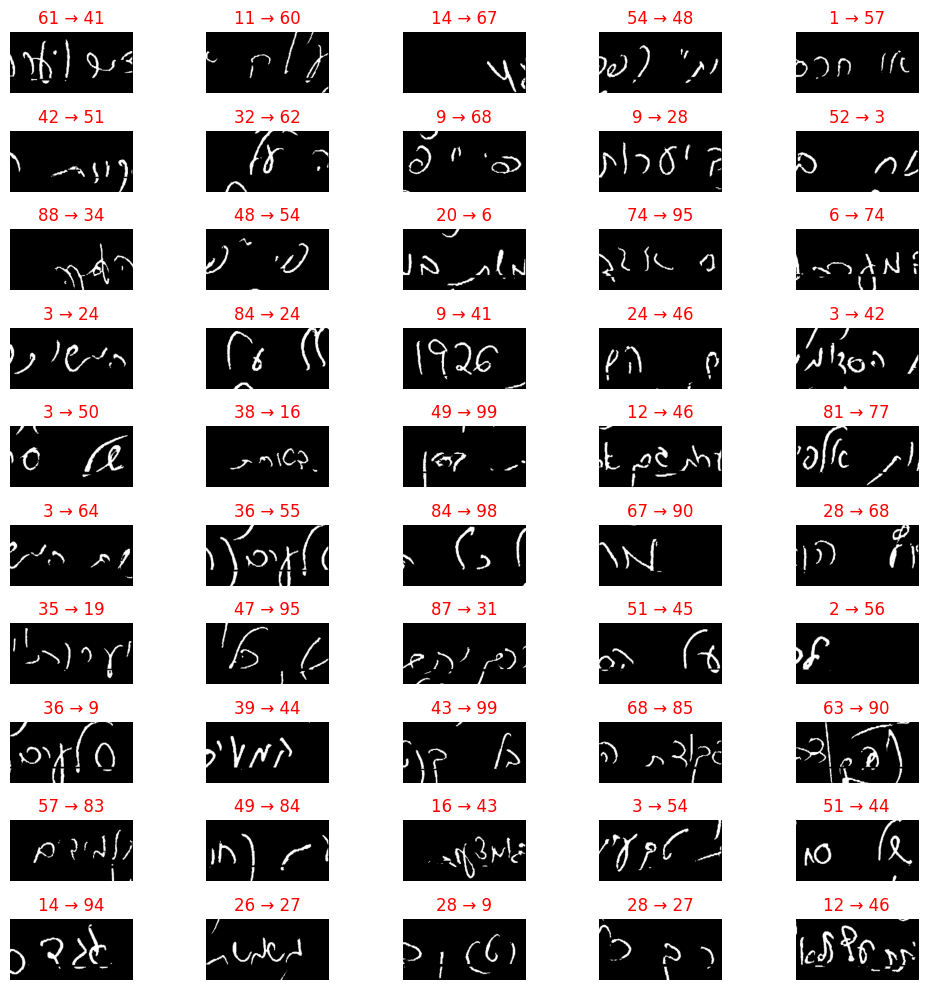

In [68]:
viz.plot_error_images()

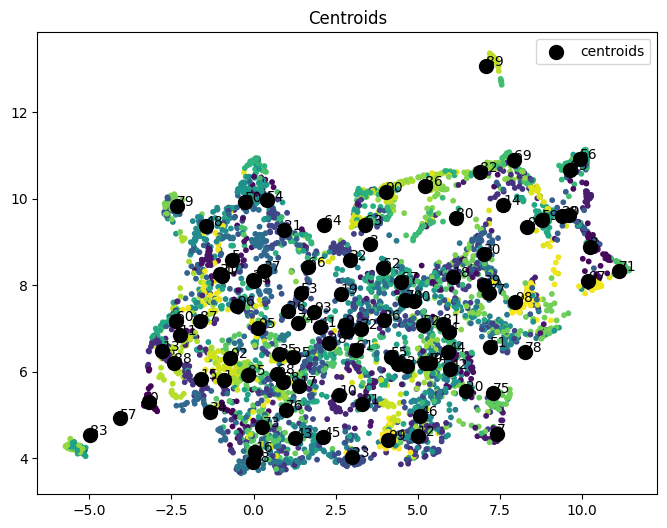

In [69]:
viz.plot_centroids()

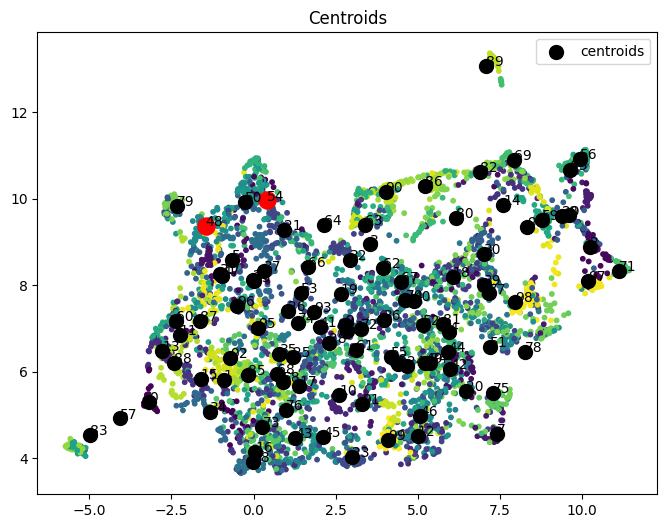

In [70]:
viz.plot_centroids([48, 54])

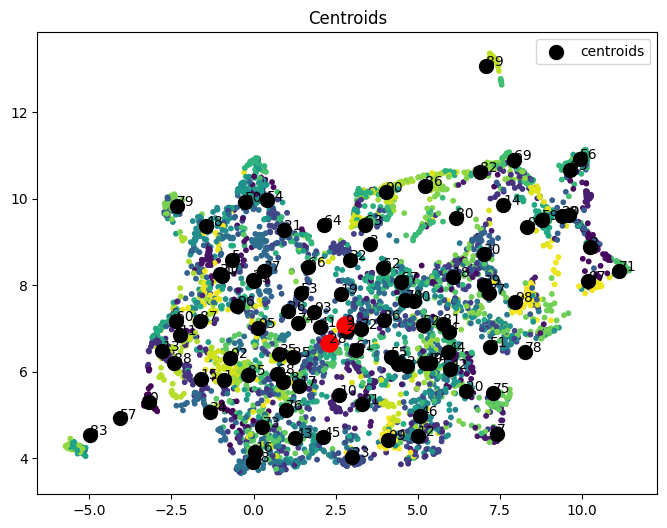

In [71]:
viz.plot_centroids([9, 28])

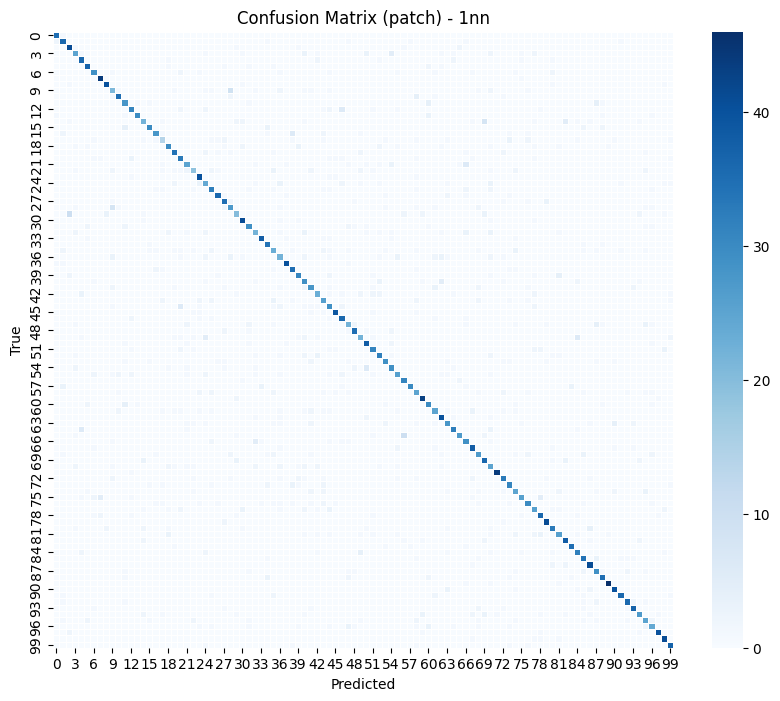

In [73]:
viz.plot_confusion(level="patch")

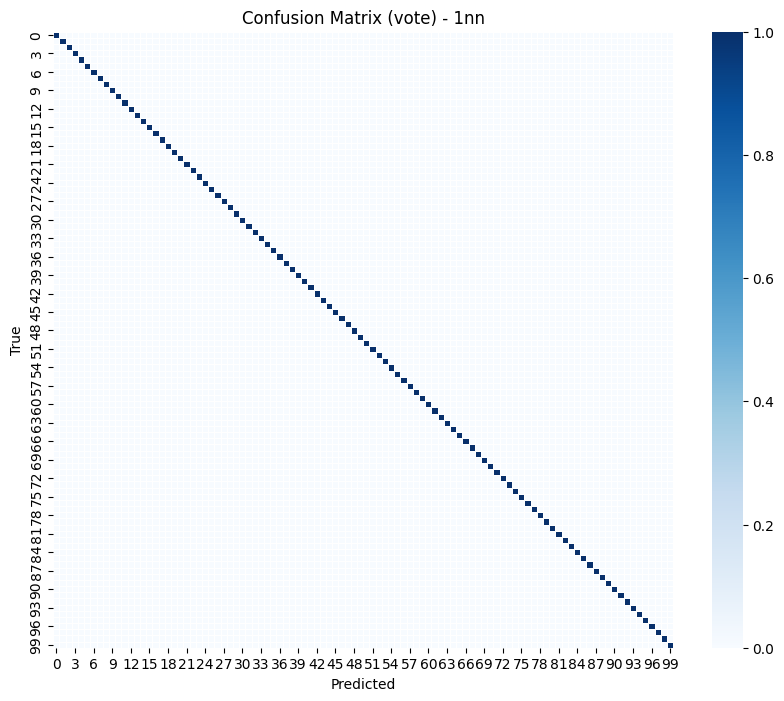

In [72]:
viz.plot_confusion(level="vote")

In [ ]:
viz.set_strategy("topk")

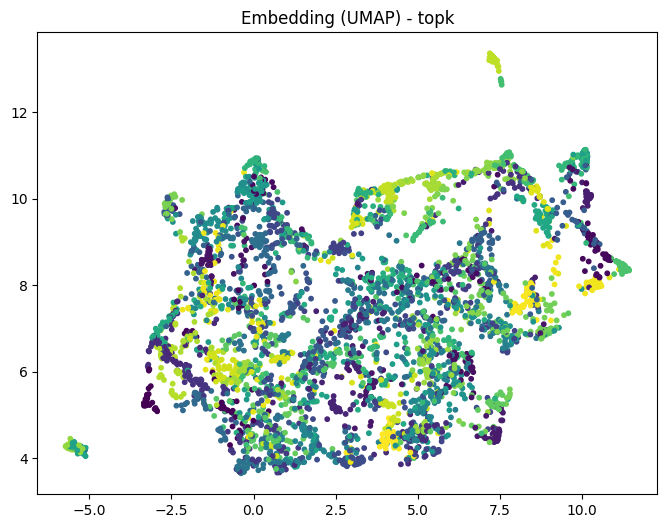

In [76]:
viz.plot_embeddings_2d()

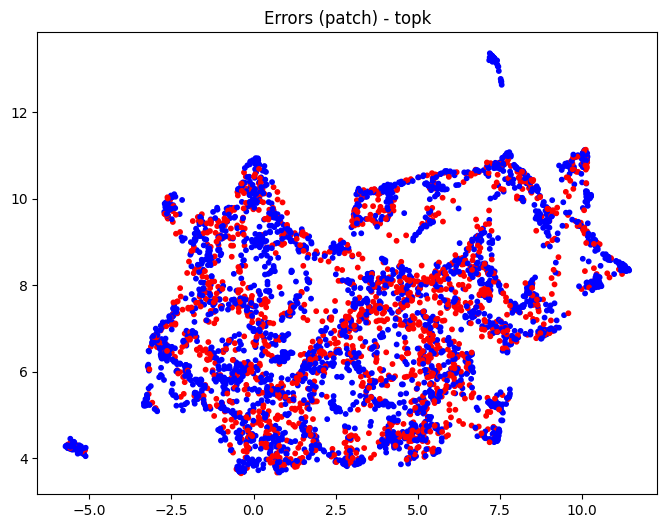

In [77]:
viz.plot_errors_2d(level="patch")

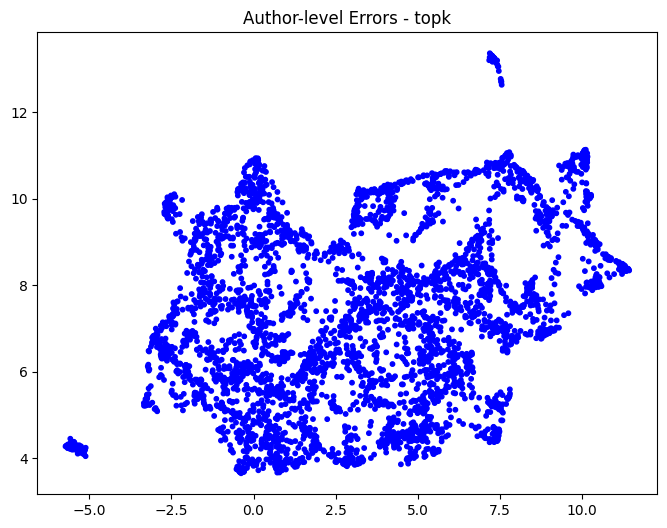

In [78]:
viz.plot_author_errors_2d()

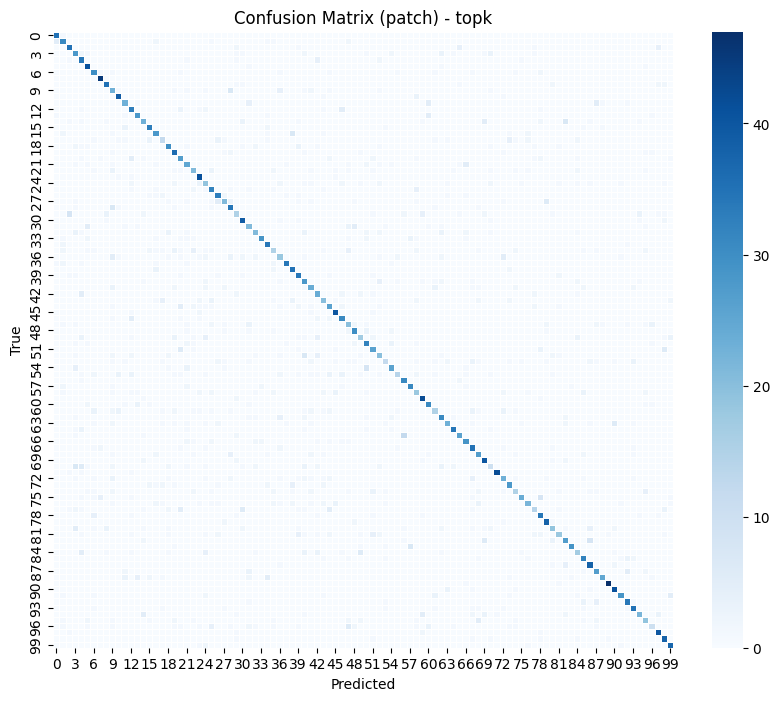

In [80]:
viz.plot_confusion("patch")

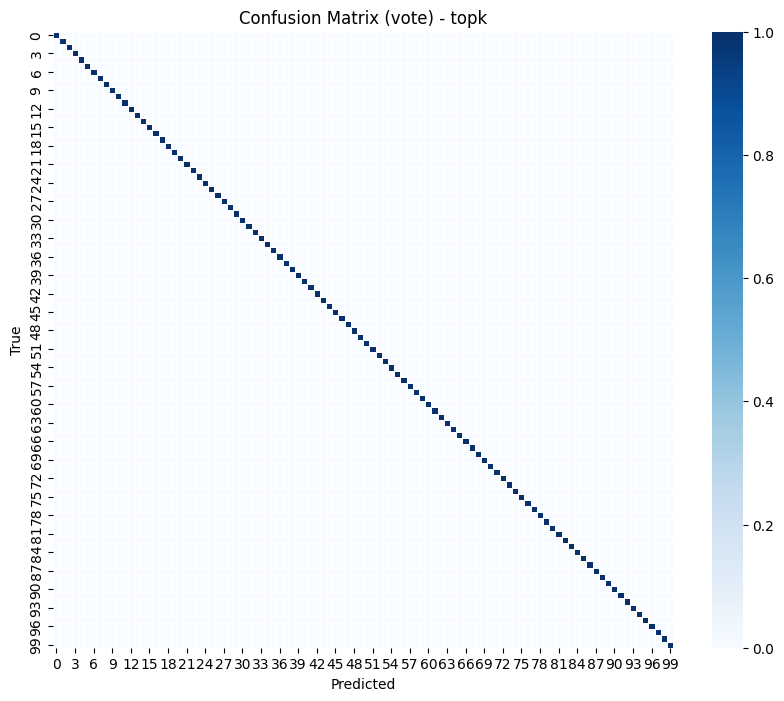

In [79]:
viz.plot_confusion("vote")

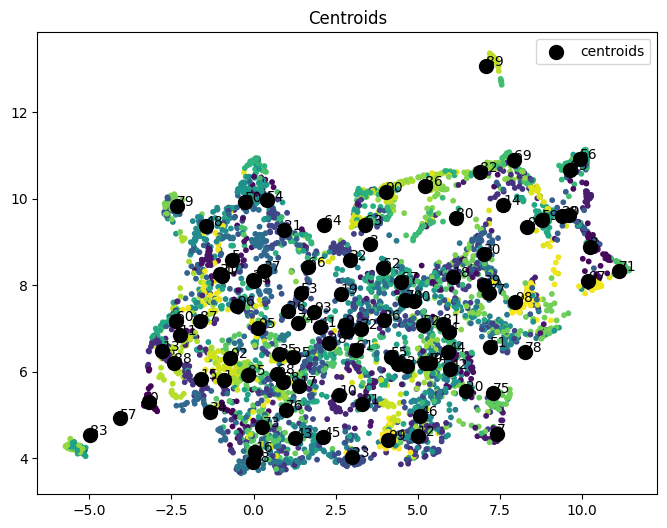

In [81]:
viz.plot_centroids()